In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import anndata as an
import scanpy as sc

# Load data

In [2]:
%%time
### Libraries 1 and 2 (control + reprogram)
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/updated_adata/fib_ihsc_processed.h5ad"
fdata = sc.read_h5ad(fpath)
fdata

CPU times: user 298 ms, sys: 1.65 s, total: 1.95 s
Wall time: 8.12 s


AnnData object with n_obs × n_vars = 15317 × 23434
    obs: 'batch', 'barcoded_phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'cluster'
    var: 'gene_id', 'gene_type', 'Chromosome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'highly_variable_rank', 'variances', 'variances_norm'
    uns: 'batch_colors', 'cluster_colors', 'dr

In [3]:
%%time
### Bone marrow
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/bone_marrow_processed.h5ad"
bdata = sc.read_h5ad(fpath)
bdata

CPU times: user 249 ms, sys: 672 ms, total: 921 ms
Wall time: 2.17 s


AnnData object with n_obs × n_vars = 5608 × 22954
    obs: 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes', 'leiden', 'bm_cluster', 'CD34_avg', 'CD164_avg', 'PROM1_avg', 'CD48_avg', 'FLT3_avg', 'MPO_avg', 'IRF8_avg', 'CD79A_avg', 'GATA1_avg', 'CD34pos_CD38neg_B0251_HTO_1', 'CD34pos_CD38pos_B0252_HTO_2', 'HTO_pred', 'HTO_pred_label', 'cluster_preds', 'CD164_mean', 'CD34_mean', 'CD38_mean', 'THY1_mean', 'PTPRC_mean', 'MME_mean', 'CD7_mean', 'FLT3_mean', 'PLEK_mean', 'BST2_mean', 'CD37_mean', 'KIT_mean', 'ICAM3_mean', 'CD44_mean', 'EVI2B_mean', 'CD63_mean', 'ITGA2B_mean', 'CSF2RB_mean', 'PROM1_mean', 'ATP1B3_mean',

In [4]:
%%time
### Timeseries dataset
fpath = "/nfs/turbo/umms-indikar/shared/projects/parse/anndatas/parse_processed.h5ad"
pdata = sc.read_h5ad(fpath)
pdata

CPU times: user 183 ms, sys: 384 ms, total: 567 ms
Wall time: 1.04 s


AnnData object with n_obs × n_vars = 6172 × 18697
    obs: 'bc_wells', 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_well', 'bc2_well', 'bc3_well', 'condition_group', 'condition_group_wTD', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str'
    var: 'gene_id', 'gene_name', 'genome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cluster_str_colors',

# Merge QC vals

In [5]:
def extract_qc_df(adata, name, qc_cols=("total_counts", "n_genes_by_counts"), batch_col=None):
    if batch_col is None:
        df = adata.obs[list(qc_cols)].copy()
        df["dataset"] = name
    else:
        df = adata.obs[list(qc_cols) + [batch_col]].copy()
        df["dataset"] = df[batch_col].astype(str)
        df = df.drop(columns=[batch_col])
    return df



qdf = pd.concat(
    [
        extract_qc_df(pdata, "parse"),
        extract_qc_df(bdata, "bone_marrow"),
        extract_qc_df(fdata, "ihsc", batch_col="batch"),
    ],
    axis=0
)

print(qdf.shape)
print(qdf['dataset'].value_counts())
qdf.head()

(27097, 3)
dataset
hsc            8357
fib            6960
parse          6172
bone_marrow    5608
Name: count, dtype: int64


,total_counts,n_genes_by_counts,dataset
01_01_16,5078.0,2760,parse
01_01_28,4617.0,2832,parse
01_01_29,5186.0,2886,parse
01_01_47,11143.0,4529,parse
01_02_10,7098.0,3557,parse


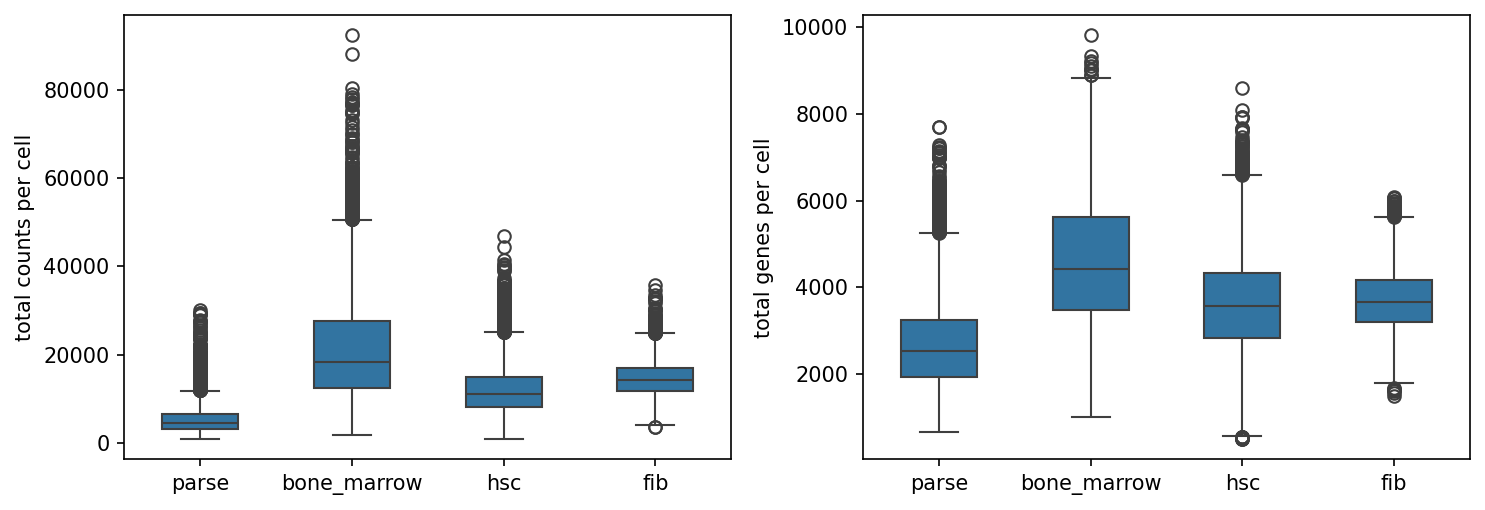

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), dpi=150)

qc_cols = ['total_counts', 'n_genes_by_counts']

for i, col in enumerate(qc_cols):
    ax = axes[i]
    
    sns.boxplot(
        qdf,
        x='dataset',
        y=col,
        width=0.5,
        ax=ax,
    )
    
    ax.set_xlabel('')
    
axes[0].set_ylabel('total counts per cell')
axes[1].set_ylabel('total genes per cell')

plt.tight_layout()
plt.show()

In [7]:
qdf.groupby('dataset')['total_counts'].describe()

,count,mean,std,min,25%,50%,75%,max
dataset,,,,,,,,
bone_marrow,5608.0,21013.039586,12874.861548,1779.0,12512.00,18365.5,27738.75,92416.0
fib,6960.0,14571.327299,3911.703752,3503.0,11769.00,14160.0,17002.25,35831.0
hsc,8357.0,12143.270911,5747.700888,856.0,8172.00,11091.0,14965.00,46816.0
parse,6172.0,5418.448153,3549.511285,845.0,3116.75,4512.0,6624.50,30021.0


In [8]:
qdf.groupby('dataset')['n_genes_by_counts'].describe()

,count,mean,std,min,25%,50%,75%,max
dataset,,,,,,,,
bone_marrow,5608.0,4492.626783,1627.159064,1003.0,3471.75,4416.5,5612.50,9812.0
fib,6960.0,3694.210201,683.347202,1494.0,3190.00,3652.5,4158.25,6078.0
hsc,8357.0,3605.789518,1152.774207,497.0,2826.00,3576.0,4333.00,8588.0
parse,6172.0,2684.207550,1071.325940,671.0,1927.00,2521.5,3256.25,7697.0


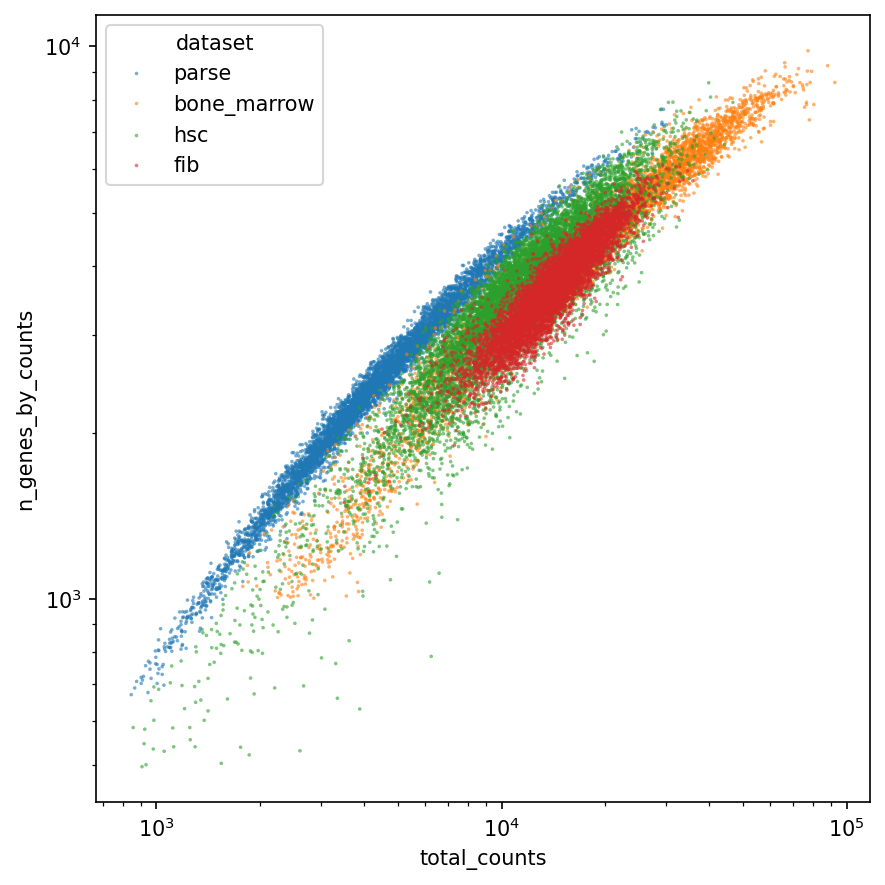

In [9]:
plt.figure(figsize=(6,6), dpi=150)

sns.scatterplot(
    qdf,
    x='total_counts',
    y='n_genes_by_counts',
    hue='dataset',
    ec='none',
    s=3,
    alpha=0.6,
)

plt.xscale('log')
plt.yscale('log')

plt.tight_layout()
plt.show()